In [ ]:
# ------------------ CELL 1: Mount Drive & Settings ------------------
from google.colab import drive
drive.mount('/content/drive')

CSV_FILE = "heart.csv"   # <- change to your filename
DATA_PATH = f"{DRIVE_PATH}/{CSV_FILE}"

# ------------------ CELL 2: Imports & helpers ------------------
import os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

def plot_confmat(y_true, y_pred, labels=None, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title); plt.show()

# ------------------ CELL 3: Load & EDA ------------------
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
print(df.info())
print("Null values:\n", df.isnull().sum())

# ------------------ CELL 4: Setup X/y ------------------
TARGET = "target"  # <- change to your actual target column
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")
X = df.drop(columns=[TARGET])
y = df[TARGET]

# ------------------ CELL 5: Simple numeric preprocessing ------------------
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
print("Numerical columns:", num_cols)
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

X_num = num_pipe.fit_transform(X[num_cols])
X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42, stratify=y)

# ------------------ CELL 6: RandomForest baseline ------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
plot_confmat(y_test, y_pred, title="Heart Disease - RF Confusion Matrix")

# ------------------ CELL 7: Optional - XGBoost (install & run) ------------------
!pip install -q xgboost
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {"objective":"binary:logistic", "eval_metric":"auc", "seed":42}
bst = xgb.train(params, dtrain, num_boost_round=150)
y_proba_xgb = bst.predict(dtest)
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC (XGB):", roc_auc_score(y_test, y_proba_xgb))

# ------------------ CELL 8: Save models & preprocessor ------------------
os.makedirs(f"{DRIVE_PATH}/models", exist_ok=True)
joblib.dump(rf, f"{DRIVE_PATH}/models/heart_rf.joblib")
joblib.dump(num_pipe, f"{DRIVE_PATH}/models/heart_preproc.joblib")
bst.save_model(f"{DRIVE_PATH}/models/heart_xgb.model")
print("Saved RF, preprocessor and XGBoost model.")


In [ ]:
# ===============================================
# STEP 1: Import Libraries
# ===============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


In [ ]:
# ===============================================
# STEP 2: Mount Google Drive and Load Dataset
# ===============================================
from google.colab import drive
import zipfile
import os
import pandas as pd

drive.mount('/content/drive')

# Path to your ZIP file in Drive
DRIVE_PATH = "/content/drive/MyDrive/ML-datasets/heart_disease.zip"
UNZIP_DIR = "/content/data"

# ✅ Unzip the dataset
if not os.path.exists(UNZIP_DIR):
    os.makedirs(UNZIP_DIR)

with zipfile.ZipFile(DRIVE_PATH, 'r') as zip_ref:
    zip_ref.extractall(UNZIP_DIR)

# ✅ Find and read the CSV file inside the extracted folder
for file in os.listdir(UNZIP_DIR):
    if file.endswith(".csv"):
        csv_path = os.path.join(UNZIP_DIR, file)
        print("Found CSV file:", csv_path)
        df = pd.read_csv(csv_path)
        break

# ✅ Display first few rows
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found CSV file: /content/data/heart_disease_uci.csv


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
# ===============================================
# STEP 3: Data Understanding
# ===============================================
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
df.info()
df.describe()


Shape of dataset: (920, 16)

Columns:
 Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

Missing values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   re

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
# ===============================================
# STEP 4: Data Cleaning and Encoding
# ===============================================

# Drop ID column
df = df.drop(columns=['id'])

# Fill missing numeric values with median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
df['ca'] = df['ca'].fillna(df['ca'].median())

# Fill missing categorical values with mode
cat_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode categorical columns using LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


In [ ]:
# ===============================================
# STEP 5: Split Features and Target
# ===============================================

target_col = 'num'   # ✅ this is your actual target column

# Convert target to binary (optional):
# 0 = no disease, 1 = has disease (for simpler classification)
df[target_col] = df[target_col].apply(lambda x: 1 if x > 0 else 0)

X = df.drop(columns=[target_col])
y = df[target_col]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape, " | Test shape:", X_test.shape)


Training shape: (736, 14)  | Test shape: (184, 14)


In [ ]:
# ===============================================
# STEP 6: Feature Scaling
# ===============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# ===============================================
# STEP 7: Train Multiple Models
# ===============================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n🔹 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))



🔹 Logistic Regression Accuracy: 0.8424
              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


🔹 SVM Accuracy: 0.8478
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184


🔹 Random Forest Accuracy: 0.8478
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0

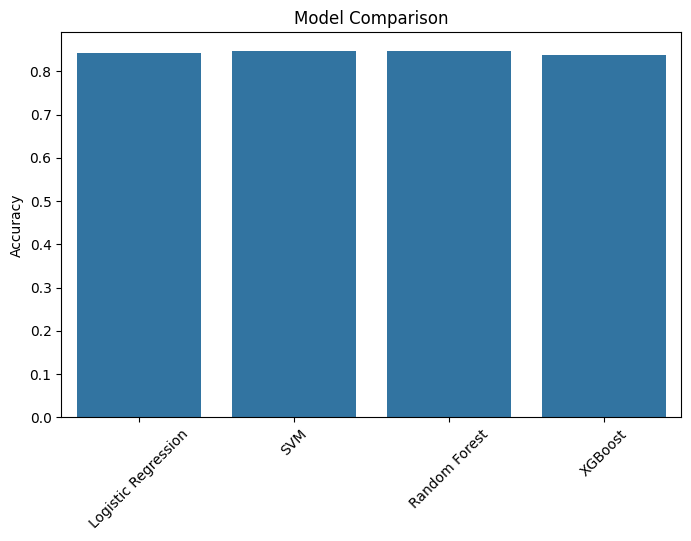

In [ ]:
# ===============================================
# STEP 8: Compare Model Performance
# ===============================================
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()


✅ Best Model: SVM


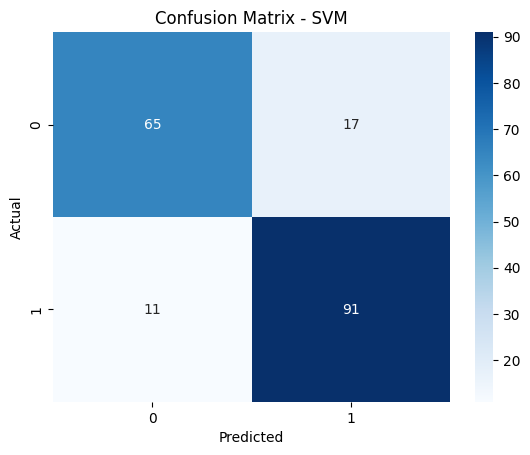

In [ ]:
# ===============================================
# STEP 9: Confusion Matrix for Best Model
# ===============================================
best_model_name = max(results, key=results.get)
print(f"✅ Best Model: {best_model_name}")

best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
